# 6. 키워드 추출 및 핵심 문장 추출

## 6-3. TextRank 기반 키워드 추출

키워드 추출을 위한 단어 그래프 생성

In [ ]:
from collections import Counter

def scan_vocabulary(sents, tokenize, min_count=2):
    counter = Counter(w for sent in sents for w in tokenize(sent)) # sents에 있는 문장 하나하나를 tokenize(sent)로 토큰화하고 나온 모든 단어(w)를 Counter에 넣어서 각 단어가 몇 번 등장했는지 센다.
    counter = {w:c for w,c in counter.items() if c >= min_count} # 등장 횟수가 기본값 2 이상인 단어만 남긴다.
    idx_to_vocab = [w for w, _ in sorted(counter.items(), key=lambda x:-x[1])] # 남은 단어들을 등장 횟수가 높은 순서대로 정렬해서 리스트로 만든다. key=lamda x:-x[1]은 내림차순 정렬한다는 뜻. idx_to_vocab[0]이 가장 많이 나온 단어가 됨.
    vocab_to_idx = {vocab:idx for idx, vocab in enumerate(idx_to_vocab)} # 위에 만든 리스트를 가지고 단어 -> 인덱스 매핑 딕셔너리 만든다. idx_to_vocab : 인덱스로 단어 찾기 , vocab_to_idx : 단어로 인덱스 찾기용.
    return idx_to_vocab, vocab_to_idx # 두 개를 튜플로 반환.

=> 문장들을 토큰화해서 자주 나온 단어들만 골라, "단어 목록(빈도순 정렬)"과 "단어→번호 딕셔너리" 두 가지를 만들어주는 함수

두 단어 간 유사도 정의를 위한 co-occurrence 계산 함수(일정한 범위 안에서 함께 등장한 단어를 연결)

In [ ]:
from collections import defaultdict

def cooccurrence(tokens, vocab_to_idx, window=2, min_cooccurrence=2, verbose=False):
    counter = defaultdict(int) # (단어쌍) -> 등장횟수를 저장할 딕셔너리. 키가 없으면 자동으로 0부터 시작.
    for s, tokens_i in enumerate(tokens): # tokens : 문장별로 토큰화된 리스트들의 리스트. token_i : 그 문장의 단어 리스트.
        vocabs = [vocab_to_idx[w] for w in tokens_i if w in vocab_to_idx] # 문장 속 단어들을 사전에 있는 것만 골라서 인덱스 번호로 바꾼다.
        n = len(vocabs) # 이 문장에서 사전에 속한 단어 개수.
        for i, v in enumerate(vocabs): # 문장 내 각 단어(인덱스 i, 단어번호 v)를 하나씩 본다.
            if window <= 0: # 문장 전체를 다 이웃으로 본다(범위 0~n)
                b, e = 0, n
            else:
                b = max(0, i - window)  # 현재 위치 i에서 좌우로 window만큼만 본다.
                e = min(i + window, n)
            for j in range(b, e):
                if i == j:
                    continue
                counter[(v, vocabs[j])] += 1 # 범위 안의 각 위치 j에 대해 (v,vocabs[j])와 (vocabs[j],v) 둘 다 카운트를 올린다 -> 대칭 행렬 만들기 위해
                counter[(vocabs[j], v)] += 1
    counter = {k:v for k,v in counter.items() if v >= min_cooccurrence} # 너무 드물게 같이 나온 단어쌍은 제거.
    n_vocabs = len(vocab_to_idx) # 전체 단어 개수(행렬의 크기가 됨.)
    return dict_to_mat(counter, n_vocabs, n_vocabs) # {(단어 i, 단어 j): 횟수}형태의 딕셔너리를 n_vocabs x n_vocabs 크기의 행렬로 변환해서 반환

=> 각 문장에서 단어들을 사전 인덱스로 바꾼 뒤, 정해진 윈도우 범위 안에서 같이 등장한 단어쌍의 횟수를 세고, 그걸 단어×단어 크기의 동시출현 행렬로 만들어주는 함수

dict of dict 형식의 그래프를 scipy의 sparse matrix로 변환하는 함수

In [ ]:
from scipy.sparse import csr_matrix

def dict_to_mat(d, n_rows, n_cols):
    rows, cols, data = [], [], [] # 세 개의 빈 리스트를 준비. -> scipy sparse matrix 만드는 재료.
    for (i, j), v in d.items(): # 딕셔너리 d는 {(i,j) : v}형태. i,j는 행/열 위치, v는 그 위치에 들어갈 값.
        rows.append(i)
        cols.append(j) # 딕셔너리의 각 항목을 세 개의 병렬 리스트로 풀어서 쌓는다.
        data.append(v)
        """
        가령,

        {
            (0, 1): 3,
            (1, 0): 3,
            (1, 2): 2
        }
        다음의 형태로 변환
            0  1  2
        0 [ 0, 3, 0 ]
        1 [ 3, 0, 2 ] # 희소 행렬을 사용해서 메모리 절약
        2 [ 0, 0, 0 ]
        """

    return csr_matrix((data, (rows, cols)), shape=(n_rows, n_cols)) # 값 data[k]는 rows[k]행, cols[k]열에 있다.나머지 위치(딕셔너리에 없는 자리)는 전부 0으로 채워짐.

=> {(행,열): 값} 딕셔너리를 rows/cols/data 세 리스트로 풀어서, scipy의 압축 희소행렬(CSR) 형태로 만들어주는 헬퍼 함수

word graph 함수

In [ ]:
def word_graph(sents, tokenize=None, min_count=2, window=2, min_cooccurrence=2, verbose=False):
    """
    단어 빈도 계산
    최소 빈도 이하 단어 제거
    각 문장 토큰화
    단어 동시 출현 그래프 생성
    그래프와 단어 목록 return
    """

    idx_to_vocab, vocab_to_idx = scan_vocabulary(sents, tokenize, min_count) # 첫 번째 함수 호출. 문장들을 토큰화해서 min_count번 이상 등장한 단어들로 사전을 만듦.
    tokens = [tokenize(sent) for sent in sents] # 모든 문장을 다시 한 번 토큰화해서 리스트로 만듦.
    g = cooccurrence(tokens, vocab_to_idx, window, min_cooccurrence, verbose) # 토큰화된 문장들과 단어사전을 가지고 동시출현 행렬을 만듦.
    return g, idx_to_vocab # 행렬과 인덱스 -> 단어 매핑 리스트를 함께 반환.

=> 그래프 기반 키워드 추출/요약 알고리즘의 전처리 파이프라인 전체를 하나로 묶은 함수

학습을 위한 PageRank 함수

In [ ]:
import numpy as np
from sklearn.preprocessing import normalize

def pagerank(x, df=0.85, max_iter=30):
    """
    x: 단어-단어 동시출현 그래프(g)
    A: 정규화된 그래프 인접 행렬
    R: 각 단어의 중요도
    df: 이웃 단어로부터 중요도를 얼마나 반영할지의 비율.연결 관계를 85% 반영, 나머지 15%는 기본값으로 깔아줌.
    max_iter: 최대 반복 횟수
    """


    assert 0 < df < 1 # damping factor는 반드시 0과 1사이 값이어야함.

    # initialize
    A = normalize(x, axis=0, norm='l1') # 그래프 행렬 x를 열을 기준으로 정규화해서 각 열의 합이 1이 되게 만듦.
    R = np.ones(A.shape[0]).reshape(-1,1) # 각 단어의 초기 중요도 점수를 전부 1로 시작.(열벡터 형태, nx1)
    bias = (1 - df) * np.ones(A.shape[0]).reshape(-1,1)

    # iteration
    for _ in range(max_iter):
        R = df * (A * R) + bias # 핵심 수식 -> A * R : 정규화된 그래프 행렬과 현재 중요도 벡터를 곱합 => 이웃 단어들로부터 얼마나 중요도를 전달받는지 계산. 그 전달받은 중요도에 85%만 반영. 나머지 15%는 기본 점수로 깔아줌.

    return R # 최종적으로 각 단어(인덱스)별 중요도 점수 벡터를 반환.

=> 행렬 위에서 PageRank 알고리즘을 돌려서 각 노드(여기선 단어)의 중요도 점수를 계산하는 코드

키워드 추출 함수

In [ ]:
def textrank_keyword(sents, tokenize, min_count, window, min_cooccurrence, df=0.85, max_iter=30, topk=30):
    g, idx_to_vocab = word_graph(sents, tokenize, min_count, window, min_cooccurrence) # 문장들로부터 단어 동시출현 그래프(g)와 인덱스 -> 단어 매핑(idx_to_vocab)을 만듦.
    R = pagerank(g, df, max_iter).reshape(-1) # 그래프에 PageRank를 돌려서 각 단어의 중요도 점수 벡터를 얻음.
    idxs = R.argsort()[-topk:] # R.argsort(): 배열 R을 오름차순으로 정렬했을때, 원래 값들의 인덱스를 반환.
    keywords = [(idx_to_vocab[idx], R[idx]) for idx in reversed(idxs)] # 내림차순이 됨. 각 인덱스 idx에 대해 (단어, 점수) 튜플들의 리스트를 만듦.
    return keywords # 최종적으로 (단어, 중요도점수) 쌍의 리스트, 총 topk개를 반환.

=> 지금까지 만든 모든 조각을 최종적으로 합쳐서, 문장들로부터 핵심 키워드 Top-K개를 뽑아주는 "완성판" 함수

문장 리스트를 넣으면 → 토큰화 → 사전 구축 → 동시출현 그래프 → PageRank → 핵심 키워드 topk개가 최종 결과물로 나오는 전형적인 TextRank 키워드 추출 알고리즘의 전체 구현

## 6-4. TextRank 기반 핵심 문장 추출

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


키워드 추출에서 단어가 노드인것과 다르게, 문장 하나가 그래프 노드를 의미

문장끼리 유사하면 간선을 연결하고, 많은 중요 문장과 연결된 문장을 핵심 문장으로 판단

In [ ]:
from collections import Counter
from scipy.sparse import csr_matrix
import math

def sent_graph(sents, tokenize, similarity, min_count=2, min_sim=0.3):
    _, vocab_to_idx = scan_vocabulary(sents, tokenize, min_count) # idx_to_vocab은 필요 없어서 버림.vocab_to_idx : 각 문장의 단어들 중 사전에 등록된 단어만 골라내는 필터로 쓰려는 것.

    tokens = [[w for w in tokenize(sent) if w in vocab_to_idx] for sent in sents] # 모든 문장을 토큰화하고, 그중 vocab_to_idx에 있는 단어만 남김. => 문장별로 필터링된 단어 리스트들의 리스트가 됨.
    rows, cols, data = [], [], [] # 나중에 csr_matrix를 만들 재료(문장 i, 문장 j, 유사도 값)준비.
    n_sents = len(tokens) # 전체 문장 개수
    for i, tokens_i in enumerate(tokens):
        for j, tokens_j in enumerate(tokens):
            if i >= j:
                continue
            sim = similarity(tokens_i, tokens_j) # 두 문장의 단어 리스트를 받아서 유사도를 계산하는 함수 similarity 호출.
            if sim < min_sim: # 유사도가 min_sim 이상인 문장만 연결
                continue
            rows.append(i); cols.append(j); data.append(sim) # 유사도가 충분히 높은 문장쌍만 (행,열,값)으로 저장.
            rows.append(j); cols.append(i); data.append(sim)

    return csr_matrix((data, (rows, cols)), shape=(n_sents, n_sents))


=> 문장들을 토큰화하고, 모든 문장쌍에 대해 (커스텀) 유사도 함수를 적용해서, 유사도가 일정 기준(min_sim) 이상인 문장쌍만 연결한 문장×문장 유사도 그래프를 만드는 함수

textrank 유사도 계산 함수 & cosine 유사도 계산 함수

In [ ]:
def textrank_sent_sim(s1, s2): # textrank_sent_sim : TextRank 논문에서 제안한 원조 문장 유사도 공식.
    n1 = len(s1) # 각 문장의 단어 개수
    n2 = len(s2)
    if (n1 <= 1) or (n2 <= 1): # 문장에 단어가 1개 이하면 유사도를 0으로 처리
        return 0
    common = len(set(s1).intersection(set(s2))) # 두 문장에서 겹치는 단어(중복 제거)의 개수
    base = math.log(n1) + math.log(n2) # 두 문장 길이의 로그값을 더함. 로그로 정규화해서 문장 길이의 영향을 완화.
    return common / base # 겹치는 단어 수를 문장 길이 보정값으로 나눠서 최종 유사도 점수 반환. 값이 클수록 더 유사한 문장.

def cosine_sent_sim(s1, s2): # cosine_sent_sim : 두 문장을 벡터로 보고 코사인 유사도를 계산하는 방식.
    if (not s1) or (not s2): # 둘 중 하나라도 빈 리스트면 유사도 0.
        return 0

    s1 = Counter(s1) # 각 문장을 "단어별 등장 횟수" 딕셔너리로 반환. 문장을 Bag-of-words 벡터로 표현하는 것.
    s2 = Counter(s2)
    norm1 = math.sqrt(sum(v ** 2 for v in s1.values())) # 코사인 유사도 공식에서 분모에 들어갈 ㅣAㅣ, ㅣBㅣ를 각각 구하는 것.
    norm2 = math.sqrt(sum(v ** 2 for v in s2.values()))
    prod = 0
    for k, v in s1.items(): # s1의 각 단어 k(와 등장횟수 v에 대해), s2에서 같은 단어의 등장횟수를 가져와 곱해서 더함. s2.get(k,0): s2에 그 단어가 없으면 0으로 처리.
        prod += v * s2.get(k, 0) # 벡터의 내적
    return prod / (norm1 * norm2) # 1에 가까울수록 두 문장이 같은 단어들을 비슷한 비율로 포함하고 있다는 뜻.

핵심 문장 추출 함수

In [ ]:
def textrank_keysentence(sents, tokenize, min_count, similarity, df=0.85, max_iter=30, topk=5, min_sim=0.3):
    g = sent_graph(sents, tokenize, min_count, min_sim, similarity)
    R = pagerank(g, df, max_iter).reshape(-1)
    idxs = R.argsort()[-topk:]
    keysents = [(idx, R[idx], sents[idx]) for idx in reversed(idxs)]
    return keysents

=> 앞서 만든 sent_graph + pagerank를 조합해서, 문서에서 가장 중요한 문장 Top-K개를 뽑아주는 함수(문서 요약). 구조는 textrank_keyword와 거의 똑같은데, 단어 대신 문장 단위로 하는 것.

## 6-5. 실습

**위에서 구현한 함수를 토대로 패키징이 된 textrank python module을 사용하여 실습 진행**
- https://github.com/lovit/textrank/

**좌측 파일 아이콘 -> 세션 저장소에 업로드 -> lalaland.txt 파일 및 textrank.zip 업로드**
- lalaland.txt: 네이버 영화 리뷰
- textrank.zip: 위 구현을 토대로 완성된 파이썬 모듈


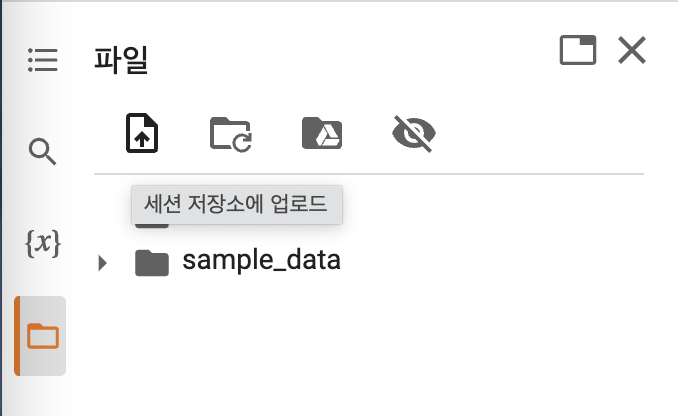

textrank 모듈 압축 해제

In [ ]:
import os
import sys

# Check if textrank directory already exists to avoid re-unzipping
if not os.path.exists('/content/textrank'):
    # Unzip the textrank.zip file. Assuming it was uploaded to /content/textrank.zip
    # as per the instructions to upload to "세션 저장소" (session storage).
    print("Unzipping textrank.zip...")
    !unzip -o /content/textrank.zip -d /content/

    # After unzipping, add the 'textrank' directory to Python's path
    # so that 'from textrank import ...' can find the module.
    if os.path.exists('/content/textrank') and '/content/textrank' not in sys.path:
        sys.path.insert(0, '/content/textrank')
        print("Added /content/textrank to sys.path.")
    else:
        print("textrank directory not found after unzipping or already in path.")
else:
    print("textrank directory already exists.")
    if '/content/textrank' not in sys.path:
        sys.path.insert(0, '/content/textrank')
        print("Added /content/textrank to sys.path.")


Unzipping textrank.zip...
Archive:  /content/textrank.zip
   creating: /content/textrank/
  inflating: /content/__MACOSX/._textrank  
  inflating: /content/textrank/__init__.py  
  inflating: /content/__MACOSX/textrank/.___init__.py  
  inflating: /content/textrank/sentence.py  
  inflating: /content/__MACOSX/textrank/._sentence.py  
  inflating: /content/textrank/utils.py  
  inflating: /content/__MACOSX/textrank/._utils.py  
  inflating: /content/textrank/summarizer.py  
  inflating: /content/__MACOSX/textrank/._summarizer.py  
  inflating: /content/textrank/rank.py  
  inflating: /content/__MACOSX/textrank/._rank.py  
  inflating: /content/textrank/word.py  
  inflating: /content/__MACOSX/textrank/._word.py  
Added /content/textrank to sys.path.


lalaland 데이터 불러오기

In [ ]:
with open('./lalaland.txt', encoding='utf-8') as f:
    sents = [sent.strip() for sent in f] # sents는 문자열 리스트, 각 원소가 파일의 한 줄(=하나의 "문장"으로 취급)이 됨. .strip()으로 앞뒤 공백/개행문자를 제거. 리스트 컴프리헨션으로 모든 줄을 처리해서 sents라는 리스트에 저장

print(len(sents)) # 총 몇 개의 문장이 있는지 개수를 출력. 데이터가 제대로 로드됐는지 확인하는 용도.

15595


=> 텍스트 파일을 읽어서 문장(줄) 단위 리스트로 만드는 부분

Komoran 형태소 분석기를 사용한 tokenizing

In [ ]:
!pip install konlpy # 한국어 자연어처리용 라이브러리 설치
from konlpy.tag import Komoran # konlpy 안에 있는 여러 형태소 분석기 클래스 중 Komoran을 가져옴.

komoran = Komoran() # Komoran 분석기 객체를 생성. 이 객체로 형태소 분석을 수행하게 됨.
def komoran_tokenize(sent):
    words = komoran.pos(sent, join=True) # pos(): 품사 태깅을 수행하는 메서드. 문장을 형태소 단위로 쪼개고 각 형태소에 품사 태그를 붙여줌. join=True: 형태소와 품사를 "단어/품사" 형태의 문자열 하나로 합쳐서 반환.
    words = [w for w in words if ('/NN' in w or '/XR' in w or '/VA' in w or '/VV' in w)] # 품사 태그 중 특정 것들만 필터링해서 남김. -> 의미를 담고 있는 핵심 품사(명사/어근/형용사/동사)만 남기는 것.
    return words # 필터링된 형태소 리스트("단어/품사" 문자열들)를 반환. => 노이즈 줄이는 데 도움이 됨, 동음이의어 구분하기 좋음.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 44.3 MB/s eta 0:00:00


=> 한국어 형태소 분석기 Komoran을 이용해서, 지금까지 만든 함수들의 tokenize 파라미터 자리에 넣을 토큰화 함수를 정의하는 부분

키워드 추출 실습
- KeywordSummarizer class의 summarize 함수는 위에서 구현한 textrank_keyword 함수

In [ ]:
from textrank import KeywordSummarizer

keyword_extractor = KeywordSummarizer(
    tokenize = komoran_tokenize,
    window = -1, # 음수나 0이면 "윈도우 제한 없이 문장 전체를 다 이웃으로 본다
    verbose = False
) # 이 시점엔 아직 아무 계산도 안 하고, 그냥 "이런 설정으로 키워드 뽑을 준비가 된 추출기 객체"만 만들어진 상태.
keywords = keyword_extractor.summarize(sents, topk=30) # 실제 계산이 일어나는 부분. sents를 넣고 topk=30을 요청.
for word, rank in keywords:
    print('{} ({:.3})'.format(word, rank))

영화/NNG (1.74e+02)
보/VV (1.3e+02)
좋/VA (65.9)
하/VV (52.3)
것/NNB (47.7)
같/VA (45.6)
음악/NNG (43.8)
꿈/NNG (41.7)
있/VV (41.0)
영화/NNP (37.9)
없/VA (36.2)
마지막/NNG (32.1)
수/NNB (30.3)
사랑/NNG (28.4)
아름답/VA (26.6)
현실/NNG (25.0)
되/VV (24.0)
노래/NNG (23.5)
생각/NNG (23.3)
스토리/NNP (21.5)
번/NNB (20.4)
거/NNB (19.8)
최고/NNG (19.3)
때/NNG (19.3)
사람/NNG (19.2)
여운/NNP (17.7)
뮤지컬/NNP (17.0)
나오/VV (16.6)
듯/NNB (16.2)
영상미/NNG (16.0)


=> textrank라는 외부 라이브러리를 써서 똑같은 작업(키워드 추출)을 하는 부분

라이브러리 textrank의 기능
scan_vocabulary + cooccurrence + dict_to_mat + word_graph => dict_to_mat + word_graph	KeywordSummarizer 내부에서 자동 처리
pagerank => 내부에서 자동 처리
textrank_keyword => keyword_extractor.summarize(sents, topk=30)

- 모든 단어를 이용할 경우, 조사나 어미가 핵심 단어로 선택될 수 있음.

In [ ]:
keyword_extractor = KeywordSummarizer(
    tokenize=lambda x:x.split(), # 공백 기준으로 문장을 쪼개는 초간단 토큰화 사용. x.split(): 인자 없이 쓰면 공백을 기준으로 문자열을 쪼갬.
    verbose = False
)
keywords = keyword_extractor.summarize(sents, topk=30)
for word, rank in keywords:
    print('{} ({:.3})'.format(word, rank))

영화 (2.4e+02)
너무 (1.2e+02)
정말 (66.3)
마지막 (57.9)
이 (54.9)
수 (53.5)
꿈을 (51.8)
영화를 (47.0)
더 (46.2)
그 (45.0)
음악 (41.2)
여운이 (37.8)
아름다운 (37.0)
보고 (37.0)
진짜 (35.6)
것 (34.5)
뮤지컬 (33.5)
잘 (33.4)
영화가 (32.0)
다 (31.9)
그냥 (30.7)
최고의 (30.5)
그리고 (29.9)
영화는 (29.1)
다시 (28.3)
좋은 (27.8)
좀 (27.7)
내 (27.4)
있는 (27.3)
또 (27.3)


=> 형태소 분석기 없이 가장 단순한 방식(공백 split)으로 토큰화했을 때 TextRank 키워드 추출이 어떻게 달라지는지 비교해보려는 코드

라라랜드 영화리뷰 핵심 문장 추출

In [ ]:
from textrank import KeysentenceSummarizer # 내부적으로 문장 간 유사도 그래프 -> pagerank -> 상위문장 추출까지 다 캡슐화되어 있음.

summarizer = KeysentenceSummarizer(
    tokenize = komoran_tokenize, # 문장을 면사/동사/형용사 등으로 쪼개서 문장 간 유사도 계산에 씀.
    min_sim = 0.5, # 문장 간 유사도가 0.5 미만이면 그래프에서 연결 안 함.
    verbose = True # 진행상황 출력
)
keysents = summarizer.summarize(sents) # 실제 계산 실행. sents를 넣고 핵심 문장 추출을 수행.
for idx, rank, komoran_sent in keysents:
    print('#{} ({:.3}) : {}'.format(idx, rank, sents[idx]), end='\n\n')

calculating textrank sentence similarity was done with 15595 sents
trained TextRank. n sentences = 15595
#5861 (6.19) : 사랑에 대해 다시 한 번 생각해 볼 수 있게 하는 영화인 것 같습니다 장면 처리도 좋았어요 여운이 많이 남는 영화입니다 꼭 보세요

#5947 (5.87) : 아 진짜 평점 처음 써본다 진짜 후회 안할 영화 나중에 다시 봐도 좋을것 같다 오프닝에서 신나는 노래부터 마지막의 상상 하는 씬까지 너무 좋음 결말이 여운이 있다고 해야하나 슬프다고 해야하나 꿈얘기 할때 현실성 있어서 눈물날뻔 결말이짱

#5076 (5.76) : 옛날 영화같은 느낌의 기법 사람을 행복하게 만드는 음악 약간의 촌스러움이 마음을 간지를 수 있는 지극히 현실적인 사랑과 꿈이야기를 로맨틱하게 풀어낸 영화로 연말 영화로 보기 좋은 것 같아요

#6665 (5.38) : 인생영화다 노래도 너무 좋고 배우 소품 배경 장면들 하나하나 맘에 안 드는게 없다 ㅠㅠ 특히 마지막 셉oo에서의 내용은 진짜 잊을 수가 없을 거같다 보고나면 먹먹하고 안타까운 느낌이 드는데 그래도 황홀하고 아름다운 영화다

#9271 (5.34) : 연출 음악 영상미 엔딩은 정말 좋았다 마지막에 남녀주인공이 나눈 눈빛이 아직도 잊혀지지않을만큼 여운이 남는 영화였다 초중반 약간 지루하긴했었다 배우들 춤연습을 많이한게보였음 꿈 성공 과 사랑을 다 가질수 없다는것을 현실적으로보여준 영화가아니었나싶다

#13909 (5.18) : 인생 최고의 영화 또보고싶다 영상미 음악 스토리 다 좋아요

#5922 (5.05) : 정말 영상미랑 음악은 최고였다 그리고 신선했다 음악이 너무 멋있어서 연기를 봐야 할지 노래를 들어야 할지 모를 정도로 그리고 보고 나서 생각 좀 많아진 영화 정말 이 연말에 보기 좋은 영화 인 것 같다

#12362 (4.84) : 보고 난 후 그냥 인생영화 다 라는 말밖에 안나오는 영화다 너무나도 아름다운 색감과

뉴스 기사에 대한 핵심 문장 추출

In [ ]:
sents = [
    '오패산터널 총격전 용의자 검거 서울 연합뉴스 경찰 관계자들이 19일 오후 서울 강북구 오패산 터널 인근에서 사제 총기를 발사해 경찰을 살해한 용의자 성모씨를 검거하고 있다 성씨는 검거 당시 서바이벌 게임에서 쓰는 방탄조끼에 헬멧까지 착용한 상태였다',
    '서울 연합뉴스 김은경 기자 사제 총기로 경찰을 살해한 범인 성모 46 씨는 주도면밀했다',
    '경찰에 따르면 성씨는 19일 오후 강북경찰서 인근 부동산 업소 밖에서 부동산업자 이모 67 씨가 나오기를 기다렸다 이씨와는 평소에도 말다툼을 자주 한 것으로 알려졌다',
    '이씨가 나와 걷기 시작하자 성씨는 따라가면서 미리 준비해온 사제 총기를 이씨에게 발사했다 총알이 빗나가면서 이씨는 도망갔다 그 빗나간 총알은 지나가던 행인 71 씨의 배를 스쳤다',
    '성씨는 강북서 인근 치킨집까지 이씨 뒤를 쫓으며 실랑이하다 쓰러뜨린 후 총기와 함께 가져온 망치로 이씨 머리를 때렸다',
    '이 과정에서 오후 6시 20분께 강북구 번동 길 위에서 사람들이 싸우고 있다 총소리가 났다 는 등의 신고가 여러건 들어왔다',
    '5분 후에 성씨의 전자발찌가 훼손됐다는 신고가 보호관찰소 시스템을 통해 들어왔다 성범죄자로 전자발찌를 차고 있던 성씨는 부엌칼로 직접 자신의 발찌를 끊었다',
    '용의자 소지 사제총기 2정 서울 연합뉴스 임헌정 기자 서울 시내에서 폭행 용의자가 현장 조사를 벌이던 경찰관에게 사제총기를 발사해 경찰관이 숨졌다 19일 오후 6시28분 강북구 번동에서 둔기로 맞았다 는 폭행 피해 신고가 접수돼 현장에서 조사하던 강북경찰서 번동파출소 소속 김모 54 경위가 폭행 용의자 성모 45 씨가 쏜 사제총기에 맞고 쓰러진 뒤 병원에 옮겨졌으나 숨졌다 사진은 용의자가 소지한 사제총기',
    '신고를 받고 번동파출소에서 김창호 54 경위 등 경찰들이 오후 6시 29분께 현장으로 출동했다 성씨는 그사이 부동산 앞에 놓아뒀던 가방을 챙겨 오패산 쪽으로 도망간 후였다',
    '김 경위는 오패산 터널 입구 오른쪽의 급경사에서 성씨에게 접근하다가 오후 6시 33분께 풀숲에 숨은 성씨가 허공에 난사한 10여발의 총알 중 일부를 왼쪽 어깨 뒷부분에 맞고 쓰러졌다',
    '김 경위는 구급차가 도착했을 때 이미 의식이 없었고 심폐소생술을 하며 병원으로 옮겨졌으나 총알이 폐를 훼손해 오후 7시 40분께 사망했다',
    '김 경위는 외근용 조끼를 입고 있었으나 총알을 막기에는 역부족이었다',
    '머리에 부상을 입은 이씨도 함께 병원으로 이송됐으나 생명에는 지장이 없는 것으로 알려졌다',
    '성씨는 오패산 터널 밑쪽 숲에서 오후 6시 45분께 잡혔다',
    '총격현장 수색하는 경찰들 서울 연합뉴스 이효석 기자 19일 오후 서울 강북구 오패산 터널 인근에서 경찰들이 폭행 용의자가 사제총기를 발사해 경찰관이 사망한 사건을 조사 하고 있다',
    '총 때문에 쫓던 경관들과 민간인들이 몸을 숨겼는데 인근 신발가게 직원 이모씨가 다가가 성씨를 덮쳤고 이어 현장에 있던 다른 상인들과 경찰이 가세해 체포했다',
    '성씨는 경찰에 붙잡힌 직후 나 자살하려고 한 거다 맞아 죽어도 괜찮다 고 말한 것으로 전해졌다',
    '성씨 자신도 경찰이 발사한 공포탄 1발 실탄 3발 중 실탄 1발을 배에 맞았으나 방탄조끼를 입은 상태여서 부상하지는 않았다',
    '경찰은 인근을 수색해 성씨가 만든 사제총 16정과 칼 7개를 압수했다 실제 폭발할지는 알 수 없는 요구르트병에 무언가를 채워두고 심지를 꽂은 사제 폭탄도 발견됐다',
    '일부는 숲에서 발견됐고 일부는 성씨가 소지한 가방 안에 있었다'
]

- 띄어쓰기 기준으로 adjacent setence graph 생성

In [ ]:
from textrank import KeysentenceSummarizer

summarizer = KeysentenceSummarizer(
    tokenize = lambda x:x.split(), # Komoran 형태소 분석 대신 그냥 공백 기준 split을 씀.
    min_sim = 0.3, # 유사도를 낮춤 -> 더 느슨하게 문장을 연결하겠다는 것.
    verbose = False
)
keysents = summarizer.summarize(sents, topk=3)
for _, _, sent in keysents:
    print(sent)

오패산터널 총격전 용의자 검거 서울 연합뉴스 경찰 관계자들이 19일 오후 서울 강북구 오패산 터널 인근에서 사제 총기를 발사해 경찰을 살해한 용의자 성모씨를 검거하고 있다 성씨는 검거 당시 서바이벌 게임에서 쓰는 방탄조끼에 헬멧까지 착용한 상태였다
총격현장 수색하는 경찰들 서울 연합뉴스 이효석 기자 19일 오후 서울 강북구 오패산 터널 인근에서 경찰들이 폭행 용의자가 사제총기를 발사해 경찰관이 사망한 사건을 조사 하고 있다
용의자 소지 사제총기 2정 서울 연합뉴스 임헌정 기자 서울 시내에서 폭행 용의자가 현장 조사를 벌이던 경찰관에게 사제총기를 발사해 경찰관이 숨졌다 19일 오후 6시28분 강북구 번동에서 둔기로 맞았다 는 폭행 피해 신고가 접수돼 현장에서 조사하던 강북경찰서 번동파출소 소속 김모 54 경위가 폭행 용의자 성모 45 씨가 쏜 사제총기에 맞고 쓰러진 뒤 병원에 옮겨졌으나 숨졌다 사진은 용의자가 소지한 사제총기


Subword_tokenizer로 문장 요약
- 많이 등장한 단어라면, subword로도 자주 등장하기에 유사도가 비슷함.

In [ ]:
def subword_tokenizer(sent, n=3):
    def subword(token, n): # 어절(공백으로 나뉜 한 단어)하나를 받아서, n글자짜리 슬라이딩 윈도우로 쪼갬.
        if len(token) <= n: # 어절 길이가 n 이하면 쪼갤 필요 없이 그대로 통째로 반환.
            return [token]
        return [token[i:i+n] for i in range(len(token) - n + 1)] # 어절 길이가 n보다 길면, 한 글자씩 밀어가면서 n글자짜리 조각들을 만듦.
    return [sub for token in sent.split() for sub in subword(token, n)] # 문장을 공백 기준으로 어절 단위로 자른 뒤 각 어절을 subword()로 쪼개고, 그 결과들을 전부 하나의 flat 리스트로 합침.

subword_tokenizer('이것은 부분단어의 예시입니다 짧은 어절은 그대로 나옵니다')

['이것은',
 '부분단',
 '분단어',
 '단어의',
 '예시입',
 '시입니',
 '입니다',
 '짧은',
 '어절은',
 '그대로',
 '나옵니',
 '옵니다']

=> 단어를 형태소 분석 없이 글자(음절) 단위로 잘게 쪼개는 "부분단어(subword)" 토큰화 방식

- Komoran을 이용하여 토크나이징과 핵심문장을 한 번에 추출

In [ ]:
from konlpy.tag import Komoran

komoran = Komoran()
def komoran_tokenizer(sent):
    words = komoran.pos(sent, join=True)
    words = [w for w in words if ('/NN' in w or '/XR' in w or '/VA' in w or '/VV' in w)]
    return words

summarizer = KeysentenceSummarizer(
    tokenize = komoran_tokenizer,
    min_sim = 0.3,
    verbose = False
)
keysents = summarizer.summarize(sents, topk=3)
for _, _, sent in keysents:
    print(sent)

오패산터널 총격전 용의자 검거 서울 연합뉴스 경찰 관계자들이 19일 오후 서울 강북구 오패산 터널 인근에서 사제 총기를 발사해 경찰을 살해한 용의자 성모씨를 검거하고 있다 성씨는 검거 당시 서바이벌 게임에서 쓰는 방탄조끼에 헬멧까지 착용한 상태였다
용의자 소지 사제총기 2정 서울 연합뉴스 임헌정 기자 서울 시내에서 폭행 용의자가 현장 조사를 벌이던 경찰관에게 사제총기를 발사해 경찰관이 숨졌다 19일 오후 6시28분 강북구 번동에서 둔기로 맞았다 는 폭행 피해 신고가 접수돼 현장에서 조사하던 강북경찰서 번동파출소 소속 김모 54 경위가 폭행 용의자 성모 45 씨가 쏜 사제총기에 맞고 쓰러진 뒤 병원에 옮겨졌으나 숨졌다 사진은 용의자가 소지한 사제총기
신고를 받고 번동파출소에서 김창호 54 경위 등 경찰들이 오후 6시 29분께 현장으로 출동했다 성씨는 그사이 부동산 앞에 놓아뒀던 가방을 챙겨 오패산 쪽으로 도망간 후였다


In [ ]:
summarizer = KeysentenceSummarizer(
    tokenize = subword_tokenizer,
    min_sim = 0.3,
    verbose = False
)
keysents = summarizer.summarize(sents, topk=3)
for _, _, sent in keysents:
    print(sent[idx])

IndexError: string index out of range

In [ ]:
summarizer.R

문장의 위치에 따라 중요도 설정

In [ ]:
import numpy as np

bias = np.ones(len(sents))
bias[-1] = 10

keysents = summarizer.summarize(sents, topk=3, bias=bias)
for _, _, sent in keysents:
    print(sent)

In [ ]:
summarizer.R

In [ ]:
sents = [
    "제주시는 개인정보 유출 사고 대응 모의훈련을 실시했다고 10일 밝혔다.",
    "이번 훈련은 공공기관에서 발생할 수 있는 개인정보 유출 사고를 가정해 진행됐다.",
    "훈련에서는 가상의 직원 김하늘의 이름과 주민등록번호가 포함된 문서가 외부로 유출된 상황을 재현했다.",
    "유출된 주민등록번호는 990101-1234567로 설정된 가상 정보였다.",
    "김하늘의 휴대전화번호 010-1234-5678과 이메일 haneul.kim@example.com도 함께 포함된 것으로 가정했다.",
    "유출 문서에는 제주특별자치도 제주시 첨단로 100이라는 가상 주소도 기록되어 있었다.",
    "또한 김하늘의 학번 202412345와 소속 부서 정보도 포함되어 있었다.",
    "훈련 참가자들은 이름과 주민등록번호가 대표적인 직접 식별자라는 점을 확인했다.",
    "참가자들은 전화번호와 이메일 주소도 개인정보에 해당한다는 사실을 다시 점검했다.",
    "주소와 생년월일이 결합되면 개인을 식별할 가능성이 높아질 수 있다는 점도 교육했다.",
    "훈련에서는 건강정보와 병력 정보가 민감정보에 해당하는 사례도 함께 소개했다.",
    "가상의 환자 이민준은 당뇨병 병력이 있는 것으로 설정되었으며 이는 실제 인물과 무관한 정보이다.",
    "참가자들은 개인정보를 공개하기 전에 가명처리를 수행하는 절차를 실습했다.",
    "가명처리 과정에서는 이름을 임의의 식별번호로 변경하였다.",
    "주민등록번호는 삭제하고 전화번호는 일부 숫자를 별표로 마스킹하였다.",
    "이메일 주소도 일부 문자를 숨겨 개인정보 노출을 최소화하였다.",
    "주소는 시 단위까지만 남기고 상세 주소는 제거하였다.",
    "교육 담당자는 가명처리 이후에도 재식별 가능성을 반드시 평가해야 한다고 설명했다.",
    "특히 여러 데이터가 결합되면 개인을 다시 식별할 가능성이 존재한다고 강조했다.",
    "참가자들은 재식별 위험을 줄이기 위해 추가 정보를 별도의 서버에 저장하는 방법도 실습했다.",
    "개인정보보호법에서는 개인정보를 목적에 맞게 최소한으로 수집하도록 규정하고 있다.",
    "민감정보는 일반 개인정보보다 강화된 보호조치가 필요하다고 교육하였다.",
    "교육 종료 후 참가자들은 개인정보의 수집과 이용, 보관, 파기 절차를 다시 확인하였다.",
    "이번 모의훈련에 사용된 이름, 주민등록번호, 전화번호, 이메일, 주소는 모두 교육용으로 생성된 가상의 정보이다."
]